Support Vector Regressor

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline


Read data

In [26]:
file = '../hourly_columbia_weather.parquet'

# Read parquet into dataframe
df = pd.read_parquet(file)

#print(df.head())

Prepare data, split into x and y

In [20]:
# defining target (Y) and explanatory variables (X)
exclude_reg = ['wdir', 'coco', 'prcp_flag']
exclude_time = ['day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin',
                               'year_cos']
exclude_lag =  [ 'rhum_lag1', 'rhum_lag3', 'rhum_lag6',
       'rhum_lag24', 'pres_lag1', 'pres_lag3', 'pres_lag6', 'pres_lag24',
       'wspd_lag1', 'wspd_lag3', 'wspd_lag6', 'dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6', 'wdir_sin_lag1',
       'wdir_sin_lag3', 'wdir_sin_lag6', 'wdir_cos_lag1', 'wdir_cos_lag3',
       'wdir_cos_lag6', 'prcp_lag1', 'prcp_lag3',
       'prcp_lag6']
exclude_roll =  ['temp_roll3', 'temp_roll6', 'temp_roll12',
       'rhum_roll3', 'rhum_roll6', 'rhum_roll12', 'wspd_roll3', 'wspd_roll6',
       'wspd_roll12', 'prcp_roll3', 'prcp_roll6', 'prcp_roll12', 'dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum3', 'prcp_sum6', 'prcp_sum12']
exclude_temp = ['temp_roll3', 'temp_roll6', 'temp_roll12', 'temp_lag1', 'temp_lag3',
       'temp_lag6', 'temp_lag24']
exclude_dwpt = ['dwpt','dwpt_lag1', 'dwpt_lag3', 'dwpt_lag6','dwpt_roll3',
       'dwpt_roll6', 'dwpt_roll12']
exclude_lag1 = ['temp_lag1', 'rhum_lag1', 'pres_lag1', 'wspd_lag1', 'dwpt_lag1', 'wdir_sin_lag1', 'wdir_cos_lag1', 'prcp_lag1']
exclude_lag3_roll3 = ['temp_lag3', 'rhum_lag3', 'pres_lag3', 'wspd_lag3', 'dwpt_lag3', 'wdir_sin_lag3', 'wdir_cos_lag3', 'prcp_lag3',
                      'temp_roll3', 'rhum_roll3','wspd_roll3', ]
exclude_current = ['rhum', 'prcp', 'wspd', 'pres','wdir_sin', 'wdir_cos','prcp_roll3','dwpt_roll3','prcp_sum3']

target_name = 'temp'
###
# edit exclusion
###
exclude = exclude_reg + [target_name] + ['dwpt'] + exclude_lag1 + exclude_current + exclude_lag3_roll3
X = df.drop(columns=exclude)
Y = df[target_name]
print(X.columns)


Index(['day_sin', 'day_cos', 'week_sin', 'week_cos', 'year_sin', 'year_cos',
       'temp_lag6', 'temp_lag24', 'rhum_lag6', 'rhum_lag24', 'pres_lag6',
       'pres_lag24', 'wspd_lag6', 'prcp_lag6', 'dwpt_lag6', 'wdir_sin_lag6',
       'wdir_cos_lag6', 'temp_roll6', 'temp_roll12', 'rhum_roll6',
       'rhum_roll12', 'wspd_roll6', 'wspd_roll12', 'prcp_roll6', 'prcp_roll12',
       'dwpt_roll6', 'dwpt_roll12', 'prcp_sum6', 'prcp_sum12'],
      dtype='object')


Train/test split

In [21]:
# train/test split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

Y_train = Y.iloc[:split]
Y_test  = Y.iloc[split:]

# create an SVR model with linear kernel
pipe = make_pipeline(
    StandardScaler(),
    SVR(kernel='linear') 
)

# train model on the data
pipe.fit(X_train, Y_train)


,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0


In [22]:
# make predictions on the data
y_pred = pipe.predict(X_test)

Plot performance

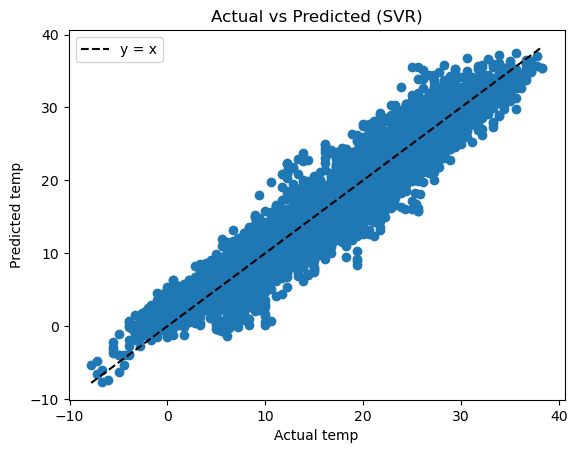

In [23]:
# plot the predicted values against the true values
plt.scatter(Y_test, y_pred)
# plot y=x for reference
mn = min(Y_test.min(), y_pred.min())
mx = max(Y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn,mx],linestyle='--', color="black", label='y = x')
plt.legend()
plt.xlabel('Actual temp')
plt.ylabel('Predicted temp')
plt.title('Actual vs Predicted (SVR)')
plt.show()


Evaluation Metrics

In [24]:
# computing metrics
r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

In [25]:
print(f'R2: \t{r2:.4f}')
print(f'MAE: \t{mae:.4f}')
print(f'RMSE: \t{rmse:.4f}')

R2: 	0.9227
MAE: 	1.8194
RMSE: 	2.3741
